===========================================
EDA - PROYECTO PREDICCIÓN DE ICTUS
Hospital F5 - Análisis Exploratorio de Datos
===========================================

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*60)
print("🏥 ANÁLISIS EXPLORATORIO - STROKE DATASET")
print("="*60)

🏥 ANÁLISIS EXPLORATORIO - STROKE DATASET


In [6]:
# ===========================================
# 1. CARGA DE DATOS DESDE GOOGLE DRIVE
# ===========================================
print("\n📁 1. CARGANDO DATOS DESDE GOOGLE DRIVE...")

try:
    import gdown
    
    # ID del archivo de Google Drive
    file_id = '1fz78OyTLal-uckug61jePY0p7ccMRrwM'
    url = f'https://drive.google.com/uc?id={file_id}'
    
    # Descargar archivo temporalmente
    output = 'temp_stroke_data.csv'
    gdown.download(url, output, quiet=False)
    
    # Cargar dataset
    df = pd.read_csv(output)
    
    # Opcional: eliminar archivo temporal
    import os
    os.remove(output)
    
except ImportError:
    print("⚠️  gdown no está instalado. Instalando...")
    print("   Ejecuta: pip install gdown")
    print("\n   O usa la Opción 2 (descarga manual)\n")
    raise


📁 1. CARGANDO DATOS DESDE GOOGLE DRIVE...


Downloading...
From: https://drive.google.com/uc?id=1fz78OyTLal-uckug61jePY0p7ccMRrwM
To: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\notebooks\temp_stroke_data.csv
100%|██████████| 291k/291k [00:00<00:00, 21.9MB/s]


In [7]:
# ===========================================
# 2. INSPECCIÓN INICIAL
# ===========================================
print("\n" + "="*60)
print("🔍 2. INSPECCIÓN INICIAL")
print("="*60)

print("\n📋 Primeras filas:")
print(df.head())

print("\n📊 Información del dataset:")
print(df.info())

print("\n📈 Estadísticas descriptivas:")
print(df.describe())

print("\n🔢 Tipos de datos:")
print(df.dtypes)


🔍 2. INSPECCIÓN INICIAL

📋 Primeras filas:
   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1    Male  80.0             0              1          Yes        Private   
2  Female  49.0             0              0          Yes        Private   
3  Female  79.0             1              0          Yes  Self-employed   
4    Male  81.0             0              0          Yes        Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             105.92  32.5     never smoked       1  
2          Urban             171.23  34.4           smokes       1  
3          Rural             174.12  24.0     never smoked       1  
4          Urban             186.21  29.0  formerly smoked       1  

📊 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 en

In [8]:
# ===========================================
# 3. ANÁLISIS DE VALORES NULOS
# ===========================================
print("\n" + "="*60)
print("❓ 3. ANÁLISIS DE VALORES NULOS")
print("="*60)

null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_info = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percentages
})
print(null_info[null_info['Valores Nulos'] > 0])

if null_info['Valores Nulos'].sum() == 0:
    print("✅ No hay valores nulos en el dataset")
else:
    print(f"⚠️  Total de valores nulos: {null_info['Valores Nulos'].sum()}")


❓ 3. ANÁLISIS DE VALORES NULOS
Empty DataFrame
Columns: [Valores Nulos, Porcentaje (%)]
Index: []
✅ No hay valores nulos en el dataset


In [9]:
# ===========================================
# 4. ANÁLISIS DE DUPLICADOS
# ===========================================
print("\n" + "="*60)
print("🔄 4. ANÁLISIS DE DUPLICADOS")
print("="*60)

duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

if duplicados > 0:
    print(f"⚠️  Se encontraron {duplicados} filas duplicadas")
else:
    print("✅ No hay registros duplicados")


🔄 4. ANÁLISIS DE DUPLICADOS
Registros duplicados: 0
✅ No hay registros duplicados



🎯 5. ANÁLISIS DE LA VARIABLE OBJETIVO (stroke)

Distribución de clases:
  No stroke (0): 4,733 (95.02%)
  Stroke (1):    248 (4.98%)

⚠️  RATIO DE DESBALANCEO: 19.1:1
   ¡El dataset está muy desbalanceado!


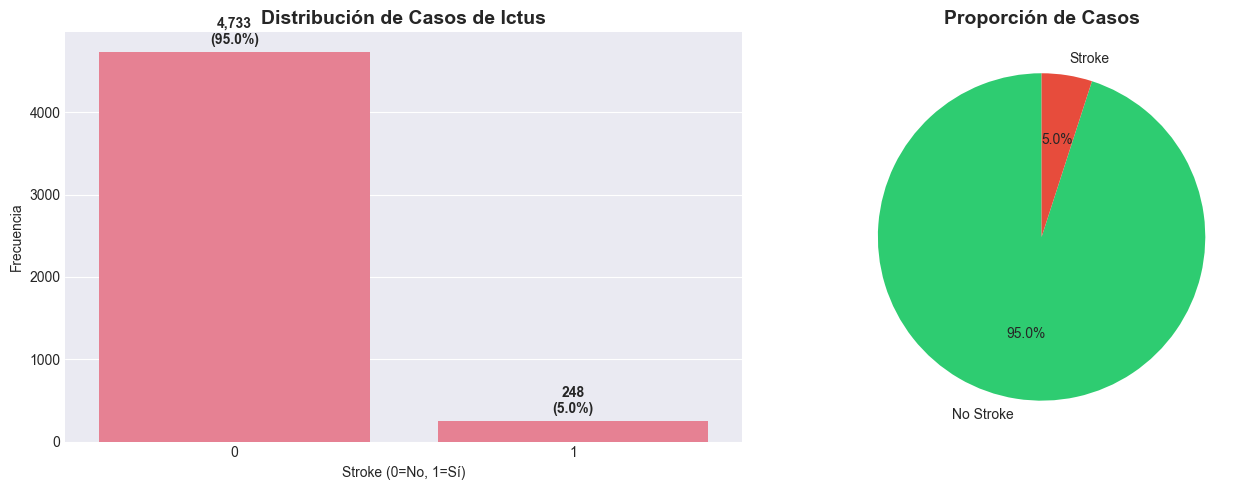

In [10]:
# ===========================================
# 5. ANÁLISIS DE LA VARIABLE OBJETIVO
# ===========================================
print("\n" + "="*60)
print("🎯 5. ANÁLISIS DE LA VARIABLE OBJETIVO (stroke)")
print("="*60)

stroke_counts = df['stroke'].value_counts()
stroke_percentages = df['stroke'].value_counts(normalize=True) * 100

print("\nDistribución de clases:")
print(f"  No stroke (0): {stroke_counts[0]:,} ({stroke_percentages[0]:.2f}%)")
print(f"  Stroke (1):    {stroke_counts[1]:,} ({stroke_percentages[1]:.2f}%)")

desbalanceo_ratio = stroke_counts[0] / stroke_counts[1]
print(f"\n⚠️  RATIO DE DESBALANCEO: {desbalanceo_ratio:.1f}:1")
print("   ¡El dataset está muy desbalanceado!")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.countplot(data=df, x='stroke', ax=axes[0])
axes[0].set_title('Distribución de Casos de Ictus', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stroke (0=No, 1=Sí)')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(stroke_counts):
    axes[0].text(i, v + 100, f"{v:,}\n({stroke_percentages[i]:.1f}%)", 
                ha='center', fontweight='bold')

# Gráfico de pastel
axes[1].pie(stroke_counts, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
           startangle=90, colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proporción de Casos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


📊 6. ANÁLISIS DE VARIABLES CATEGÓRICAS

Variables categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

--- GENDER ---
gender
Female    2907
Male      2074
Name: count, dtype: int64
Valores únicos: 2

--- EVER_MARRIED ---
ever_married
Yes    3280
No     1701
Name: count, dtype: int64
Valores únicos: 2

--- WORK_TYPE ---
work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64
Valores únicos: 4

--- RESIDENCE_TYPE ---
Residence_type
Urban    2532
Rural    2449
Name: count, dtype: int64
Valores únicos: 2

--- SMOKING_STATUS ---
smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64
Valores únicos: 4


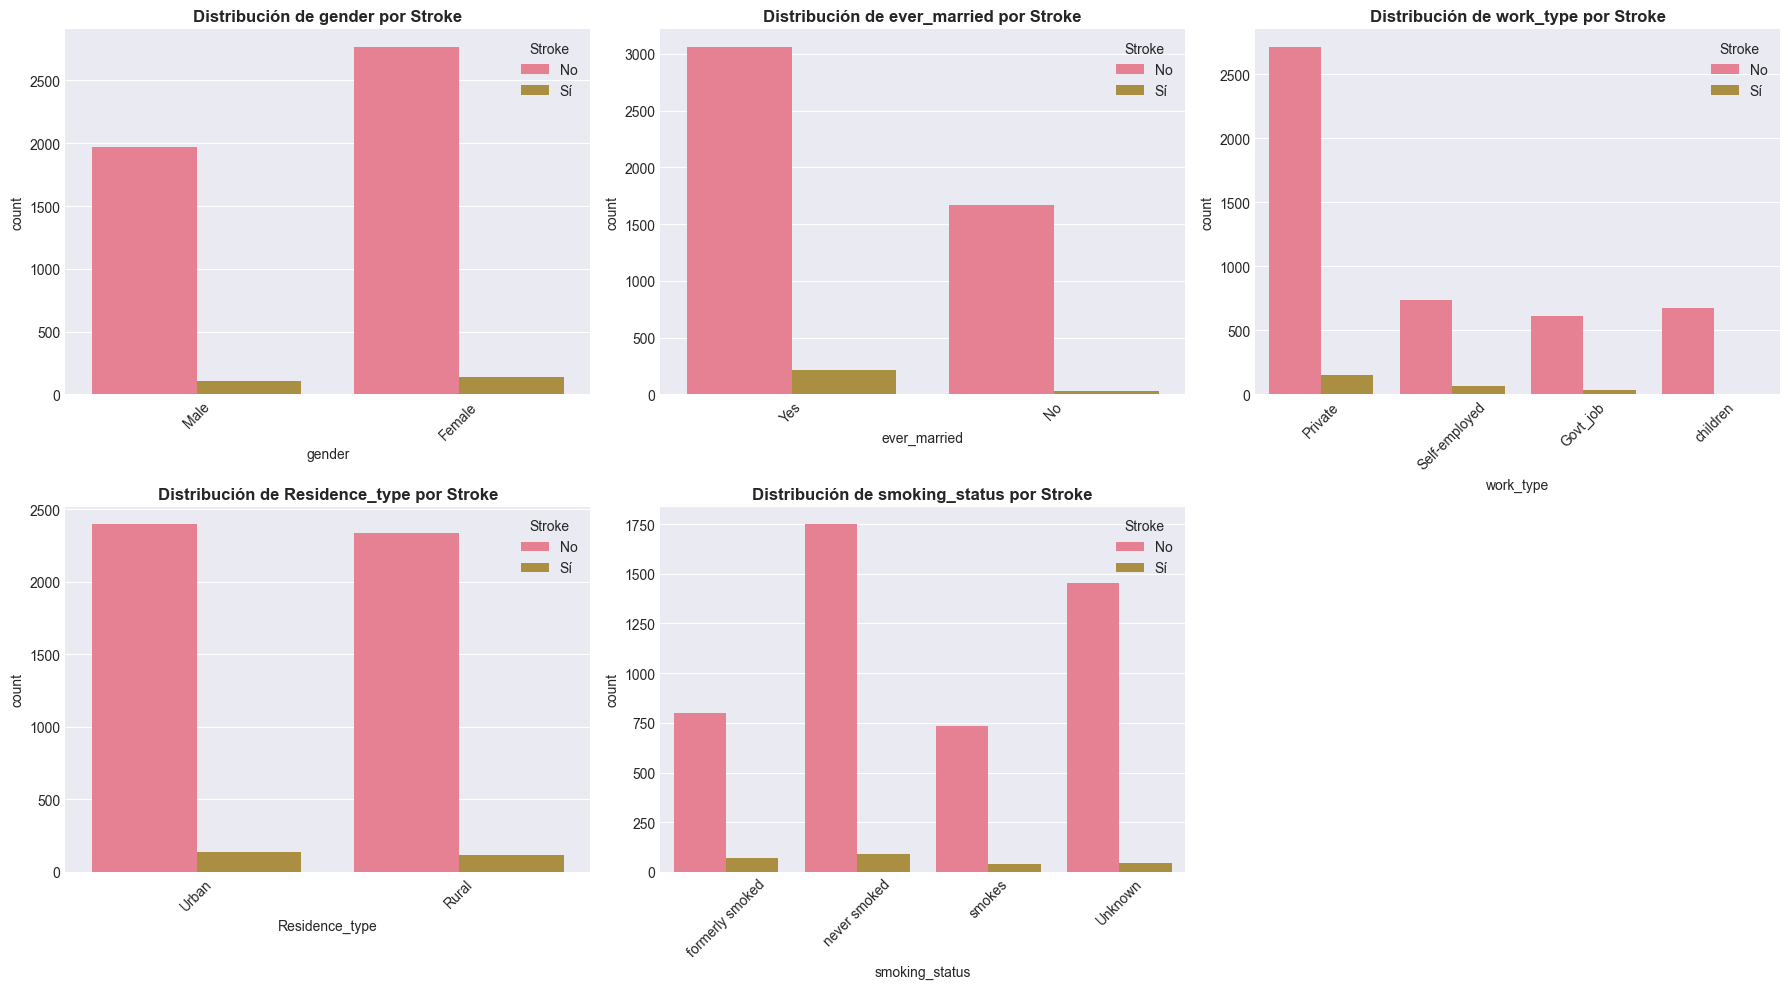

In [11]:
# ===========================================
# 6. ANÁLISIS DE VARIABLES CATEGÓRICAS
# ===========================================
print("\n" + "="*60)
print("📊 6. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'id']

print(f"\nVariables categóricas: {categorical_cols}")

for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    value_counts = df[col].value_counts()
    print(value_counts)
    print(f"Valores únicos: {df[col].nunique()}")

# Visualización
n_cols = len(categorical_cols)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[idx])
    axes[idx].set_title(f'Distribución de {col} por Stroke', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title='Stroke', labels=['No', 'Sí'])

# Ocultar ejes vacíos
for idx in range(n_cols, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()



🔢 7. ANÁLISIS DE VARIABLES NUMÉRICAS

Variables numéricas: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

--- AGE ---
count    4981.000000
mean       43.419859
std        22.662755
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64
Skewness: -0.14
Kurtosis: -0.99

--- HYPERTENSION ---
count    4981.000000
mean        0.096165
std         0.294848
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: hypertension, dtype: float64
Skewness: 2.74
Kurtosis: 5.51

--- HEART_DISEASE ---
count    4981.000000
mean        0.055210
std         0.228412
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: heart_disease, dtype: float64
Skewness: 3.90
Kurtosis: 13.19

--- AVG_GLUCOSE_LEVEL ---
count    4981.000000
mean      105.943562
std        45.075373
min        55.120000
25%     

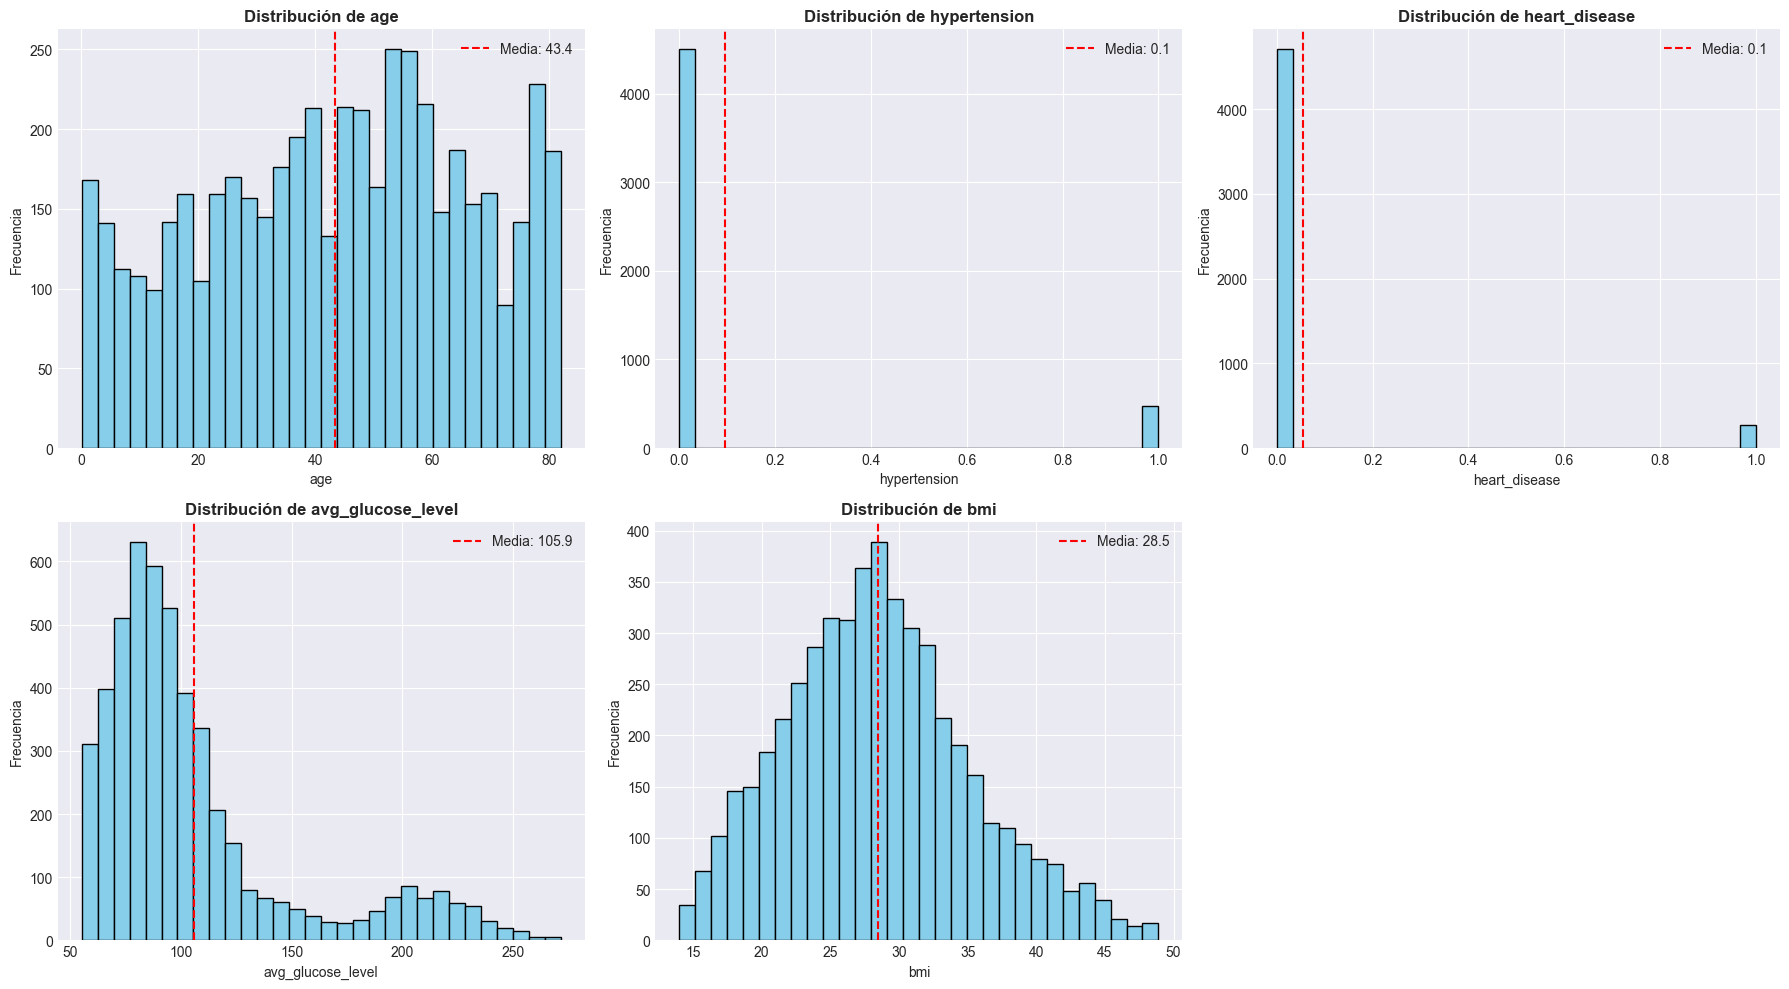

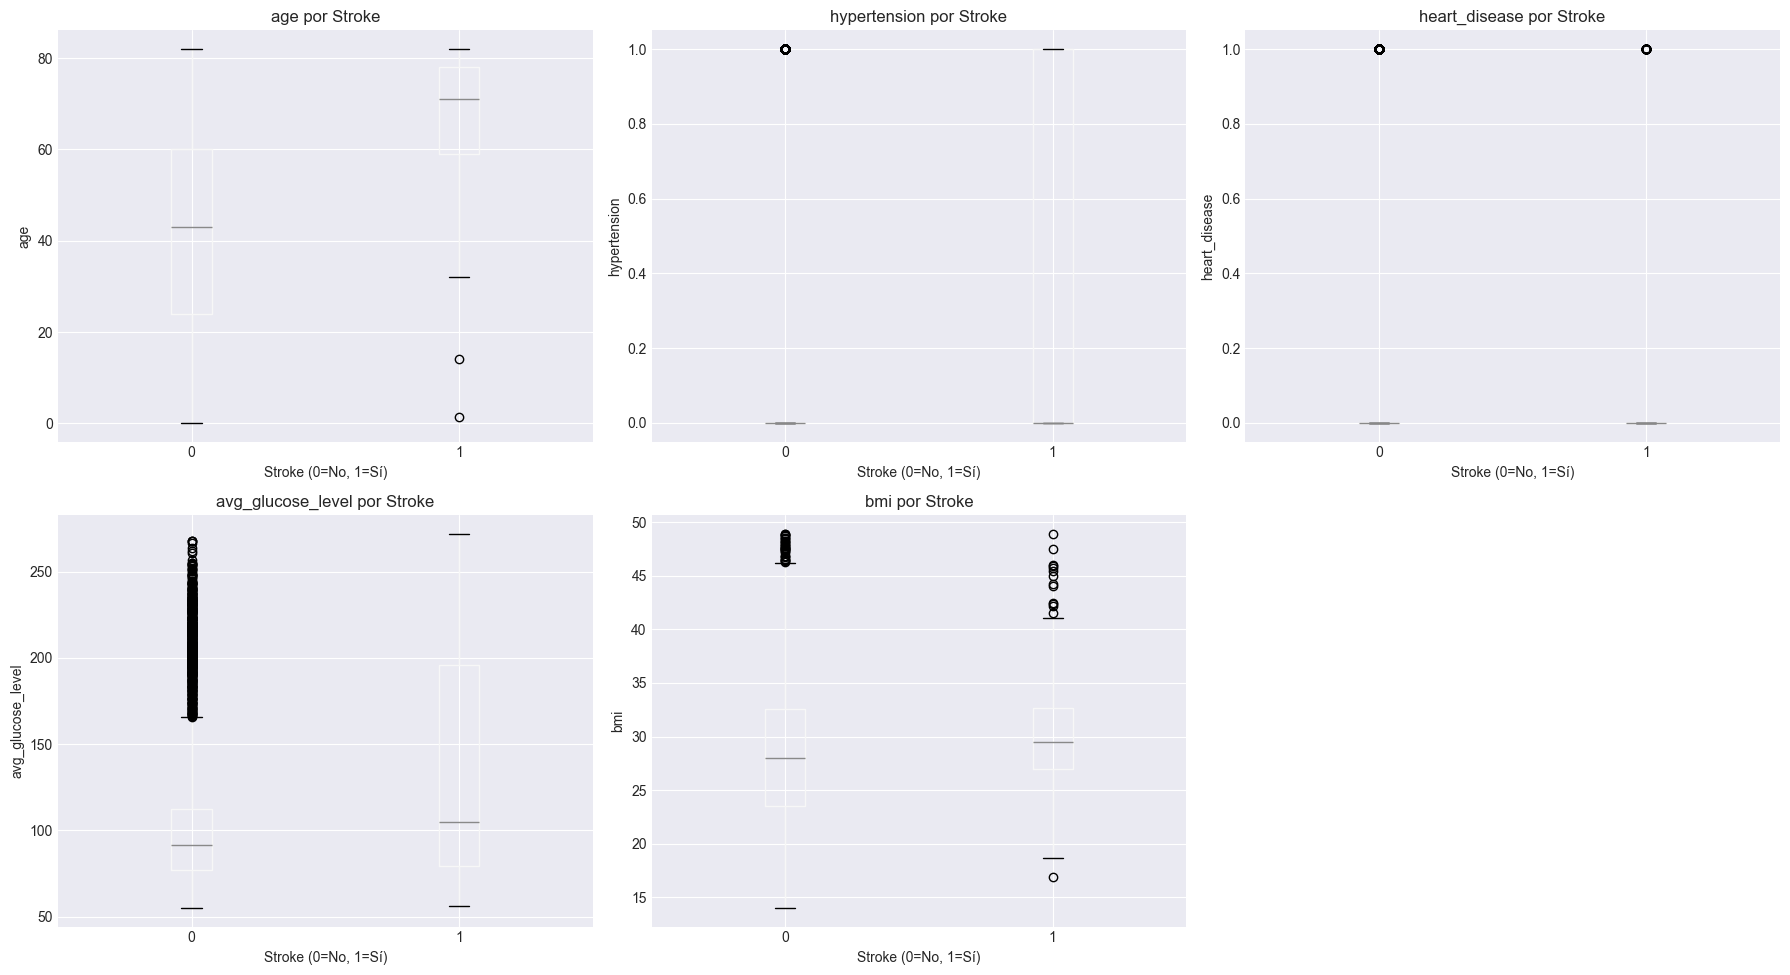

In [12]:
# ===========================================
# 7. ANÁLISIS DE VARIABLES NUMÉRICAS
# ===========================================
print("\n" + "="*60)
print("🔢 7. ANÁLISIS DE VARIABLES NUMÉRICAS")
print("="*60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['id', 'stroke']]

print(f"\nVariables numéricas: {numeric_cols}")

for col in numeric_cols:
    print(f"\n--- {col.upper()} ---")
    print(df[col].describe())
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurtosis():.2f}")

# Visualización - Histogramas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribución de {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                     label=f'Media: {df[col].mean():.1f}')
    axes[idx].legend()

# Ocultar ejes vacíos
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Visualización - Boxplots por stroke
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='stroke', ax=axes[idx])
    axes[idx].set_title(f'{col} por Stroke')
    axes[idx].set_xlabel('Stroke (0=No, 1=Sí)')
    axes[idx].set_ylabel(col)

# Ocultar ejes vacíos
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('')  # Remover título automático
plt.tight_layout()
plt.show()



🔗 8. ANÁLISIS DE CORRELACIÓN

Correlación con Stroke:
stroke               1.000000
age                  0.246478
heart_disease        0.134610
avg_glucose_level    0.133227
hypertension         0.131965
bmi                  0.056926
Name: stroke, dtype: float64


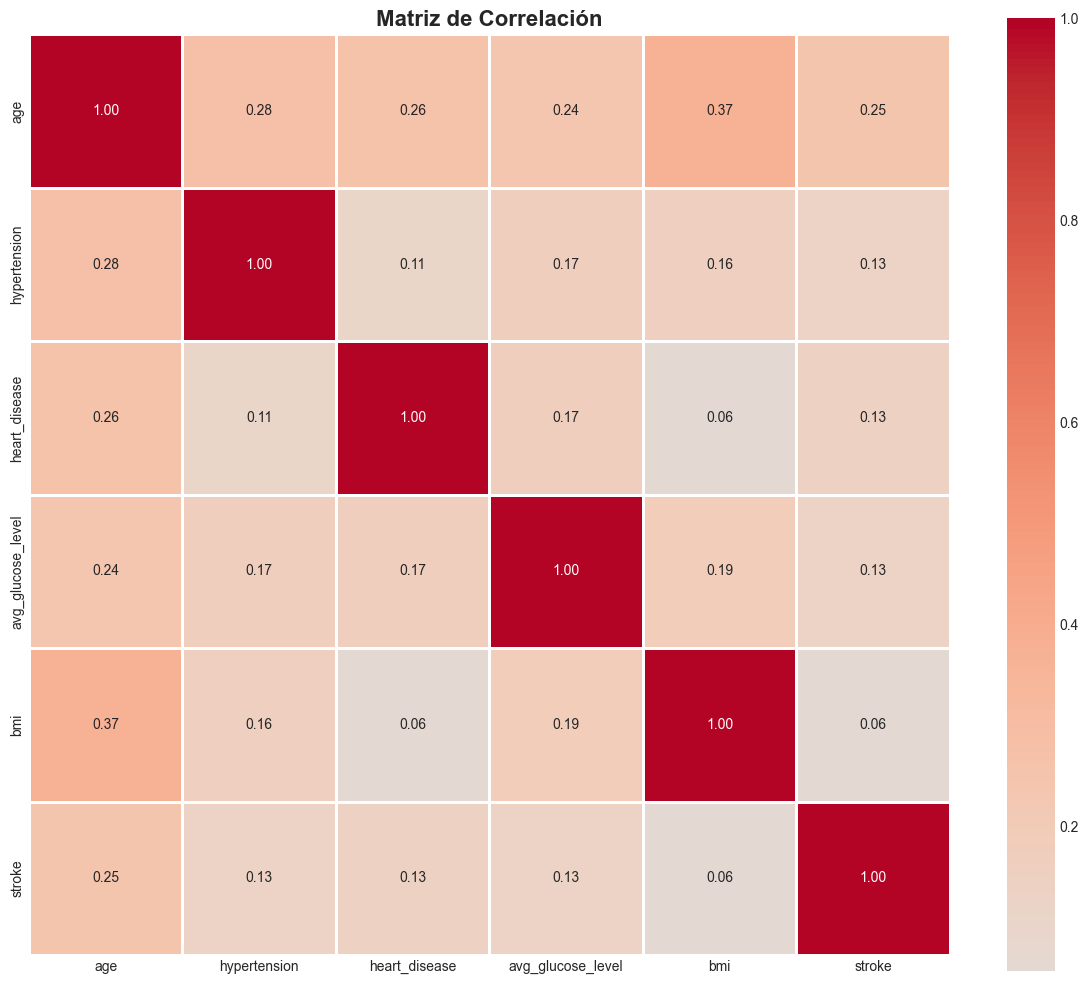

In [13]:
# ===========================================
# 8. ANÁLISIS DE CORRELACIÓN
# ===========================================
print("\n" + "="*60)
print("🔗 8. ANÁLISIS DE CORRELACIÓN")
print("="*60)

# Codificar variables categóricas para correlación
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

# Matriz de correlación
correlation_matrix = df_encoded[numeric_cols + ['stroke']].corr()

print("\nCorrelación con Stroke:")
stroke_corr = correlation_matrix['stroke'].sort_values(ascending=False)
print(stroke_corr)

# Visualización
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ===========================================
# 9. ANÁLISIS BIVARIADO DETALLADO
# ===========================================
print("\n" + "="*60)
print("📊 9. ANÁLISIS BIVARIADO DETALLADO")
print("="*60)

# Edad vs Stroke
print("\n--- EDAD vs STROKE ---")
print(df.groupby('stroke')['age'].describe())

# Género vs Stroke
print("\n--- GÉNERO vs STROKE ---")
gender_stroke = pd.crosstab(df['gender'], df['stroke'], normalize='index') * 100
print(gender_stroke)

# Hipertensión vs Stroke
print("\n--- HIPERTENSIÓN vs STROKE ---")
hypertension_stroke = pd.crosstab(df['hypertension'], df['stroke'], normalize='index') * 100
print(hypertension_stroke)

# Enfermedad del corazón vs Stroke
print("\n--- ENFERMEDAD DEL CORAZÓN vs STROKE ---")
heart_disease_stroke = pd.crosstab(df['heart_disease'], df['stroke'], normalize='index') * 100
print(heart_disease_stroke)

# Casado vs Stroke
print("\n--- ESTADO CIVIL vs STROKE ---")
married_stroke = pd.crosstab(df['ever_married'], df['stroke'], normalize='index') * 100
print(married_stroke)

# Tipo de trabajo vs Stroke
print("\n--- TIPO DE TRABAJO vs STROKE ---")
work_stroke = pd.crosstab(df['work_type'], df['stroke'], normalize='index') * 100
print(work_stroke)

# Tipo de residencia vs Stroke
print("\n--- TIPO DE RESIDENCIA vs STROKE ---")
residence_stroke = pd.crosstab(df['Residence_type'], df['stroke'], normalize='index') * 100
print(residence_stroke)

# Fumador vs Stroke
print("\n--- FUMADOR vs STROKE ---")
smoking_stroke = pd.crosstab(df['smoking_status'], df['stroke'], normalize='index') * 100
print(smoking_stroke)



📊 9. ANÁLISIS BIVARIADO DETALLADO

--- EDAD vs STROKE ---
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4733.0  42.141348  22.345036  0.08  24.0  43.0  60.0  82.0
1        248.0  67.819839  12.670565  1.32  59.0  71.0  78.0  82.0

--- GÉNERO vs STROKE ---
stroke          0         1
gender                     
Female  95.184039  4.815961
Male    94.792671  5.207329

--- HIPERTENSIÓN vs STROKE ---
stroke                0          1
hypertension                      
0             95.957352   4.042648
1             86.221294  13.778706

--- ENFERMEDAD DEL CORAZÓN vs STROKE ---
stroke                 0          1
heart_disease                      
0              95.728857   4.271143
1              82.909091  17.090909

--- ESTADO CIVIL vs STROKE ---
stroke                0         1
ever_married                     
No            98.295121  1.704879
Yes           93.323171  6.676829

--- TIPO

In [15]:
# ===========================================
# 10. DETECCIÓN DE OUTLIERS
# ===========================================
print("\n" + "="*60)
print("🎯 10. DETECCIÓN DE OUTLIERS")
print("="*60)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


🎯 10. DETECCIÓN DE OUTLIERS

age:
  Q1: 25.00, Q3: 61.00, IQR: 36.00
  Límites: [-29.00, 115.00]
  Outliers detectados: 0 (0.00%)

hypertension:
  Q1: 0.00, Q3: 0.00, IQR: 0.00
  Límites: [0.00, 0.00]
  Outliers detectados: 479 (9.62%)

heart_disease:
  Q1: 0.00, Q3: 0.00, IQR: 0.00
  Límites: [0.00, 0.00]
  Outliers detectados: 275 (5.52%)

avg_glucose_level:
  Q1: 77.23, Q3: 113.86, IQR: 36.63
  Límites: [22.29, 168.81]
  Outliers detectados: 602 (12.09%)

bmi:
  Q1: 23.70, Q3: 32.60, IQR: 8.90
  Límites: [10.35, 45.95]
  Outliers detectados: 43 (0.86%)


In [16]:
# ===========================================
# 11. INSIGHTS Y CONCLUSIONES
# ===========================================
print("\n" + "="*60)
print("💡 11. INSIGHTS Y CONCLUSIONES CLAVE")
print("="*60)

print("""
🔍 HALLAZGOS PRINCIPALES:

1. DESBALANCEO DE CLASES:
   - El dataset está EXTREMADAMENTE desbalanceado (~95% sin ictus)
   - ⚠️ CRÍTICO: Necesitaremos técnicas como SMOTE, ADASYN o class_weight

2. VARIABLES MÁS RELEVANTES (aparentemente):
   - Edad: Correlación positiva clara con ictus
   - Hipertensión: Factor de riesgo importante
   - Enfermedades del corazón: Factor de riesgo significativo
   - Nivel de glucosa promedio: Posible indicador
   - Estado civil (casado): Puede estar relacionado con la edad

3. VARIABLES CATEGÓRICAS:
   - Género: Distribución similar excepto "Other" (pocos casos)
   - Tipo de trabajo: Puede ser proxy de edad/estilo de vida
   - Fumador: "Unknown" es una categoría grande a considerar
   
4. CALIDAD DE DATOS:
   - BMI: Tiene valores nulos que necesitan tratamiento
   - ID: Columna irrelevante para el modelo (eliminar)
   - Edad: Buena distribución, sin valores anómalos

5. OUTLIERS:
   - BMI y avg_glucose_level tienen outliers
   - Evaluar si son valores reales o errores de medición

📋 PRÓXIMOS PASOS:

1. PREPROCESAMIENTO:
   ✅ Eliminar columna 'id'
   ✅ Tratar valores nulos en BMI (imputación o eliminación)
   ✅ Codificar variables categóricas (One-Hot o Label Encoding)
   ✅ Normalizar/Escalar variables numéricas
   ✅ Tratar "Unknown" en smoking_status

2. MANEJO DE DESBALANCEO:
   ✅ Implementar SMOTE o ADASYN
   ✅ Usar class_weight en modelos
   ✅ Considerar métricas adecuadas (Recall, F1, AUC-ROC)

3. FEATURE ENGINEERING:
   ✅ Crear rangos de edad
   ✅ Combinar factores de riesgo (hipertensión + heart_disease)
   ✅ Interacciones entre variables

4. MODELADO:
   ✅ Baseline: Logistic Regression
   ✅ Ensemble: Random Forest, XGBoost, LightGBM
   ✅ Validación cruzada estratificada
   ✅ Optimización con Optuna

🎯 OBJETIVO: Maximizar RECALL (detectar todos los casos de ictus)
   sin sacrificar demasiado la precisión
""")

print("\n" + "="*60)
print("✅ EDA COMPLETADO")
print("="*60)


💡 11. INSIGHTS Y CONCLUSIONES CLAVE

🔍 HALLAZGOS PRINCIPALES:

1. DESBALANCEO DE CLASES:
   - El dataset está EXTREMADAMENTE desbalanceado (~95% sin ictus)
   - ⚠️ CRÍTICO: Necesitaremos técnicas como SMOTE, ADASYN o class_weight

2. VARIABLES MÁS RELEVANTES (aparentemente):
   - Edad: Correlación positiva clara con ictus
   - Hipertensión: Factor de riesgo importante
   - Enfermedades del corazón: Factor de riesgo significativo
   - Nivel de glucosa promedio: Posible indicador
   - Estado civil (casado): Puede estar relacionado con la edad

3. VARIABLES CATEGÓRICAS:
   - Género: Distribución similar excepto "Other" (pocos casos)
   - Tipo de trabajo: Puede ser proxy de edad/estilo de vida
   - Fumador: "Unknown" es una categoría grande a considerar

4. CALIDAD DE DATOS:
   - BMI: Tiene valores nulos que necesitan tratamiento
   - ID: Columna irrelevante para el modelo (eliminar)
   - Edad: Buena distribución, sin valores anómalos

5. OUTLIERS:
   - BMI y avg_glucose_level tienen outl